## Bước 1: Tải lên và Đọc dữ liệu Excel

Để đảm bảo tính linh hoạt, chúng ta sẽ sử dụng `google.colab.files.upload()` để bạn có thể chọn file Excel từ máy tính của mình. Sau đó, file sẽ được đọc vào DataFrame của pandas.

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
from google.colab import files
import io

# Tải lên file Excel
uploaded = files.upload()

# Đọc file Excel vào DataFrame của pandas
# Giả sử bạn chỉ tải lên một file, chúng ta sẽ lấy tên file đầu tiên
file_name = next(iter(uploaded))
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"Đã đọc thành công file '{file_name}' vào DataFrame.")

Saving Du_lieu_Phan_tich_Khach_hang.xlsx to Du_lieu_Phan_tich_Khach_hang (1).xlsx
Đã đọc thành công file 'Du_lieu_Phan_tich_Khach_hang (1).xlsx' vào DataFrame.


## Bước 2: Hiển thị Tổng quan Dữ liệu

Trước khi đi sâu vào phân tích, chúng ta cần nắm rõ cấu trúc và đặc điểm cơ bản của dữ liệu:

*   **Số dòng, số cột**: Kích thước của DataFrame.
*   **Kiểu dữ liệu**: Kiểm tra các kiểu dữ liệu của từng cột để đảm bảo chúng được hiểu đúng.
*   **Thống kê mô tả**: Cái nhìn tổng quan về phân phối của các cột số.
*   **Kiểm tra dữ liệu thiếu**: Xác định số lượng giá trị thiếu trong mỗi cột.
*   **Kiểm tra dữ liệu trùng lặp**: Phát hiện các bản ghi hoàn toàn giống nhau.

In [ ]:
# 1. Hiển thị số dòng và số cột
print("1. Kích thước DataFrame (Số dòng, Số cột):")
print(df.shape)
print("\n" + "-"*50 + "\n")

# 2. Hiển thị kiểu dữ liệu của từng cột
print("2. Thông tin về các cột và kiểu dữ liệu:")
df.info()
print("\n" + "-"*50 + "\n")

# 3. Hiển thị thống kê mô tả cho các cột số
print("3. Thống kê mô tả dữ liệu:")
display(df.describe())
print("\n" + "-"*50 + "\n")

# 4. Kiểm tra dữ liệu thiếu (Missing Values)
print("4. Số lượng giá trị thiếu trong mỗi cột:")
missing_values = df.isnull().sum()
missing_values_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_values_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))
if missing_df['Missing Count'].sum() == 0:
    print("Không có giá trị thiếu trong DataFrame.")
print("\n" + "-"*50 + "\n")

# 5. Kiểm tra dữ liệu trùng lặp (Duplicate Values)
print("5. Số lượng dòng trùng lặp hoàn toàn:")
duplicate_rows = df.duplicated().sum()
print(f"Có {duplicate_rows} dòng trùng lặp.")
if duplicate_rows > 0:
    print("Hiển thị các dòng trùng lặp đầu tiên:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())
print("\n" + "-"*50 + "\n")

1. Kích thước DataFrame (Số dòng, Số cột):
(120, 8)

--------------------------------------------------

2. Thông tin về các cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Mã_KH                  120 non-null    object 
 1   Tuổi                   120 non-null    int64  
 2   Thu_Nhập_Năm (Triệu)   120 non-null    int64  
 3   Điểm_Chi_Tiêu (1-100)  120 non-null    int64  
 4   Số_Lần_Mua_Tháng       120 non-null    int64  
 5   Tỷ_Lệ_Click_QC (%)     120 non-null    float64
 6   Sản_Phẩm_Yêu_Thích     120 non-null    object 
 7   Đã_Chốt_Đơn            120 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 7.6+ KB

--------------------------------------------------

3. Thống kê mô tả dữ liệu:


,Tuổi,Thu_Nhập_Năm (Triệu),Điểm_Chi_Tiêu (1-100),Số_Lần_Mua_Tháng,Tỷ_Lệ_Click_QC (%),Đã_Chốt_Đơn
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,34.808333,195.733333,52.016667,6.941667,6.480833,0.341667
std,8.993271,56.809535,21.692652,3.122959,5.086781,0.476257
min,18.000000,75.000000,3.000000,1.000000,0.500000,0.000000
25%,29.750000,160.250000,36.000000,5.000000,3.000000,0.000000
50%,35.000000,197.000000,51.000000,7.000000,4.700000,0.000000
75%,39.250000,232.250000,67.250000,9.000000,8.900000,1.000000
max,60.000000,340.000000,100.000000,15.000000,20.800000,1.000000



--------------------------------------------------

4. Số lượng giá trị thiếu trong mỗi cột:


,Missing Count,Missing Percentage


Không có giá trị thiếu trong DataFrame.

--------------------------------------------------

5. Số lượng dòng trùng lặp hoàn toàn:
Có 0 dòng trùng lặp.

--------------------------------------------------



## Bước 3: Làm sạch và Chuẩn bị Dữ liệu

Bước này tập trung vào việc biến đổi dữ liệu thô thành định dạng phù hợp cho các thuật toán học máy. Các bước chính bao gồm:

1.  **Xử lý giá trị thiếu**: Mặc dù đã kiểm tra và xác nhận không có, chúng ta vẫn sẽ có một bước logic để xử lý nếu có.
2.  **Loại bỏ dữ liệu bất thường (Outliers)**: Tùy thuộc vào phân tích EDA, chúng ta có thể cần xử lý các giá trị ngoại lai.
3.  **Mã hóa dữ liệu dạng text (Categorical Encoding)**: Chuyển đổi các cột phân loại thành dạng số.
4.  **Chuẩn hóa dữ liệu số (Numerical Scaling)**: Đưa các cột số về cùng một thang đo.

In [ ]:
# Import các thư viện cần thiết cho xử lý dữ liệu
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Tạo một bản sao của DataFrame để làm việc, tránh ảnh hưởng đến df gốc
df_processed = df.copy()

print("Bắt đầu làm sạch và chuẩn bị dữ liệu...")

# --- 3.1 Xử lý giá trị thiếu (Missing Values) ---
# Như đã kiểm tra ở Bước 2, không có giá trị thiếu. Tuy nhiên, nếu có, chúng ta có thể điền vào hoặc xóa.
# Ví dụ: df_processed.fillna(df_processed.mean(), inplace=True) for numerical
# hoặc df_processed.fillna(df_processed.mode().iloc[0], inplace=True) for categorical
if df_processed.isnull().sum().sum() > 0:
    print("Phát hiện giá trị thiếu. Cần xử lý.")
    # Tùy thuộc vào loại cột, chúng ta sẽ áp dụng chiến lược điền khác nhau
    # Ví dụ: điền mean/median cho số, mode cho categorical
    for col in df_processed.columns:
        if df_processed[col].dtype == 'object':
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
        elif df_processed[col].dtype in ['int64', 'float64']:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    print("Đã xử lý giá trị thiếu.")
else:
    print("Không có giá trị thiếu, bỏ qua bước này.")

# --- 3.2 Loại bỏ dữ liệu bất thường (Outliers) ---
# Bước này thường yêu cầu phân tích EDA sâu hơn để xác định ngưỡng.
# Tạm thời, chúng ta sẽ bỏ qua bước này để giữ cho luồng công việc chung đơn giản.
# Nếu cần, có thể sử dụng IQR method hoặc Z-score để phát hiện và xử lý.
print("\nBỏ qua bước xử lý dữ liệu bất thường tạm thời. Có thể xem xét sau EDA.")

# --- 3.3 Mã hóa dữ liệu dạng text (Categorical Encoding) ---
# Xác định các cột phân loại và số
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_features = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Loại bỏ cột 'Mã_KH' khỏi danh sách tính năng (nếu có)
if 'Mã_KH' in categorical_features:
    categorical_features.remove('Mã_KH')
    df_processed = df_processed.drop('Mã_KH', axis=1)
    print("Đã loại bỏ cột 'Mã_KH'.")

# Kiểm tra nếu 'Đã_Chốt_Đơn' là biến mục tiêu và loại bỏ nó khỏi danh sách tính năng để không bị scale
TARGET_COLUMN = 'Đã_Chốt_Đơn'
if TARGET_COLUMN in numerical_features:
    numerical_features.remove(TARGET_COLUMN)

print(f"\nCác cột phân loại sẽ được mã hóa: {categorical_features}")
print(f"Các cột số sẽ được chuẩn hóa: {numerical_features}")

# Tạo preprocessor sử dụng ColumnTransformer
# One-Hot Encode cho các cột phân loại
# Scale (chuẩn hóa) cho các cột số
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Giữ lại các cột khác (như biến mục tiêu)
)

# Áp dụng preprocessor vào dữ liệu
# Do ColumnTransformer trả về numpy array, chúng ta cần xây dựng lại DataFrame
X = df_processed.drop(columns=[TARGET_COLUMN], errors='ignore') # Features
y = df_processed[TARGET_COLUMN] # Target variable

X_processed_array = preprocessor.fit_transform(X)

# Lấy tên cột sau One-Hot Encoding
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
final_feature_names = numerical_features + encoded_feature_names.tolist()

# Tạo DataFrame mới từ mảng đã xử lý
X_processed = pd.DataFrame(X_processed_array, columns=final_feature_names)

print("\nDataFrame sau khi làm sạch và chuẩn bị dữ liệu (X_processed):")
display(X_processed.head())
print(f"Kích thước X_processed: {X_processed.shape}")

print("\nBiến mục tiêu (y):")
display(y.head())
print(f"Kích thước y: {y.shape}")

print("Hoàn thành làm sạch và chuẩn bị dữ liệu.")

Bắt đầu làm sạch và chuẩn bị dữ liệu...
Không có giá trị thiếu, bỏ qua bước này.

Bỏ qua bước xử lý dữ liệu bất thường tạm thời. Có thể xem xét sau EDA.
Đã loại bỏ cột 'Mã_KH'.

Các cột phân loại sẽ được mã hóa: ['Sản_Phẩm_Yêu_Thích']
Các cột số sẽ được chuẩn hóa: ['Tuổi', 'Thu_Nhập_Năm (Triệu)', 'Điểm_Chi_Tiêu (1-100)', 'Số_Lần_Mua_Tháng', 'Tỷ_Lệ_Click_QC (%)']

DataFrame sau khi làm sạch và chuẩn bị dữ liệu (X_processed):


,Tuổi,Thu_Nhập_Năm (Triệu),Điểm_Chi_Tiêu (1-100),Số_Lần_Mua_Tháng,Tỷ_Lệ_Click_QC (%),Sản_Phẩm_Yêu_Thích_Gia dụng,Sản_Phẩm_Yêu_Thích_Mỹ phẩm,Sản_Phẩm_Yêu_Thích_Thời trang,Sản_Phẩm_Yêu_Thích_Điện máy
0,0.579704,0.835509,-0.880317,-1.589002,-1.141207,0.0,0.0,1.0,0.0
1,-0.090259,-0.596287,-0.417398,-0.624346,-0.272593,0.0,0.0,1.0,0.0
2,0.803025,1.348127,1.712027,1.626516,-0.746383,0.0,0.0,0.0,1.0
3,1.807969,0.641067,-0.602566,-0.624346,-0.272593,0.0,0.0,0.0,1.0
4,-0.201919,0.110773,-0.556274,-0.624346,-0.785865,0.0,0.0,0.0,1.0


Kích thước X_processed: (120, 9)

Biến mục tiêu (y):


,Đã_Chốt_Đơn
0,0
1,1
2,0
3,0
4,0


Kích thước y: (120,)
Hoàn thành làm sạch và chuẩn bị dữ liệu.


## Bước 4: Phân tích Khám phá Dữ liệu (EDA)

Chúng ta sẽ sử dụng các biểu đồ để trực quan hóa dữ liệu và tìm ra các insight quan trọng.

Bắt đầu phân tích khám phá dữ liệu (EDA)...

1. Biểu đồ phân phối của các biến số:



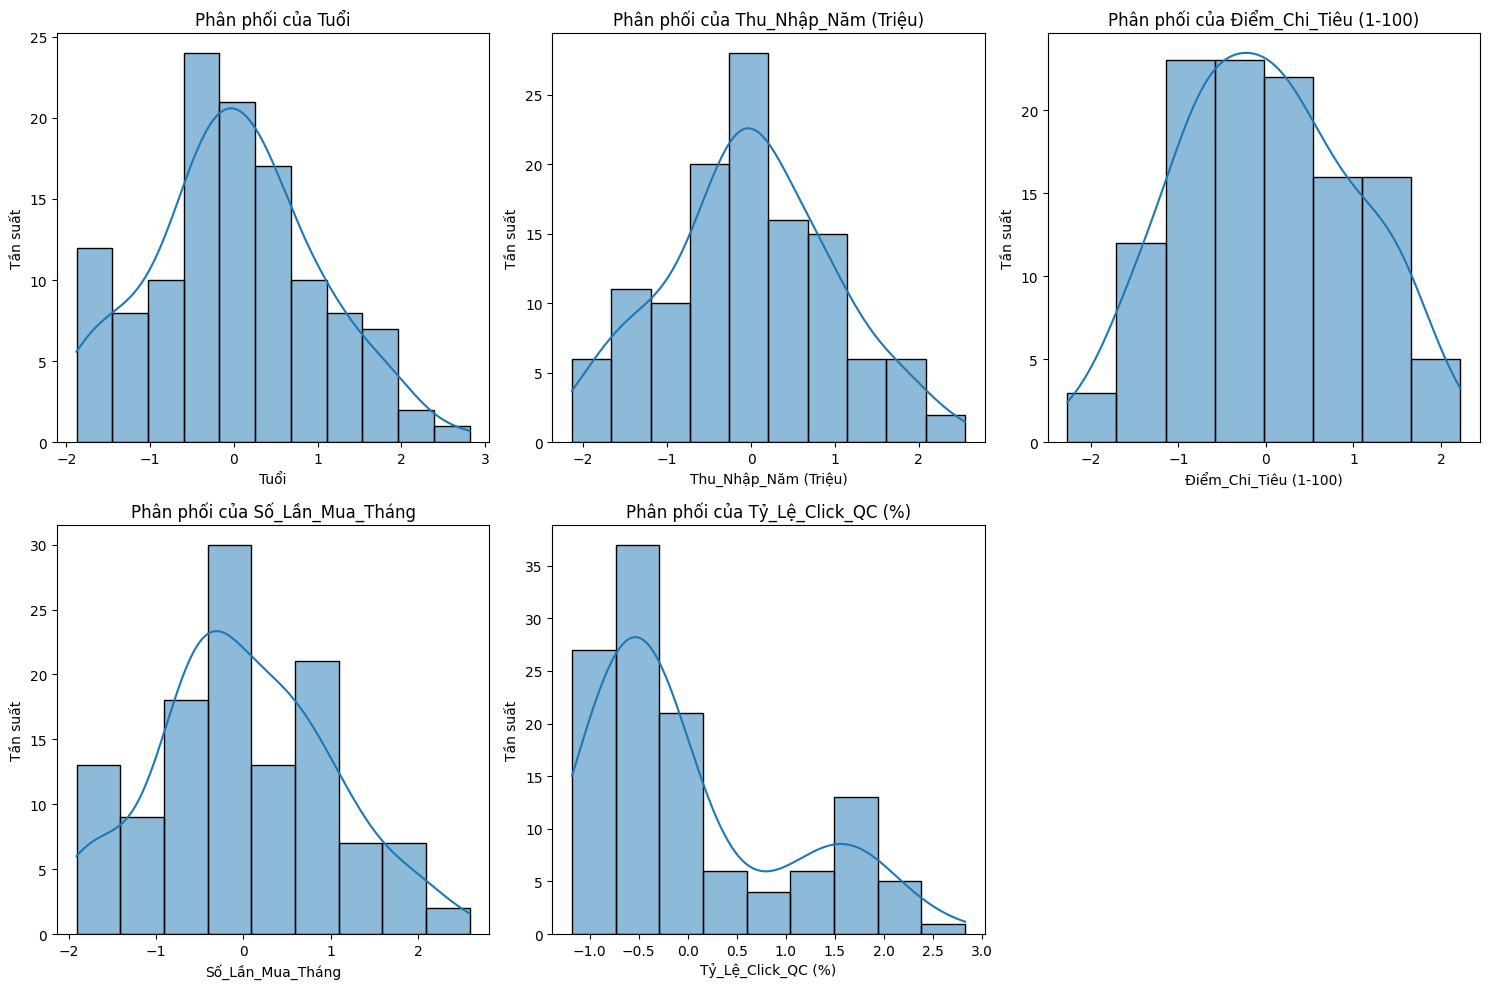


2. Biểu đồ phân phối của các biến phân loại (sau mã hóa):



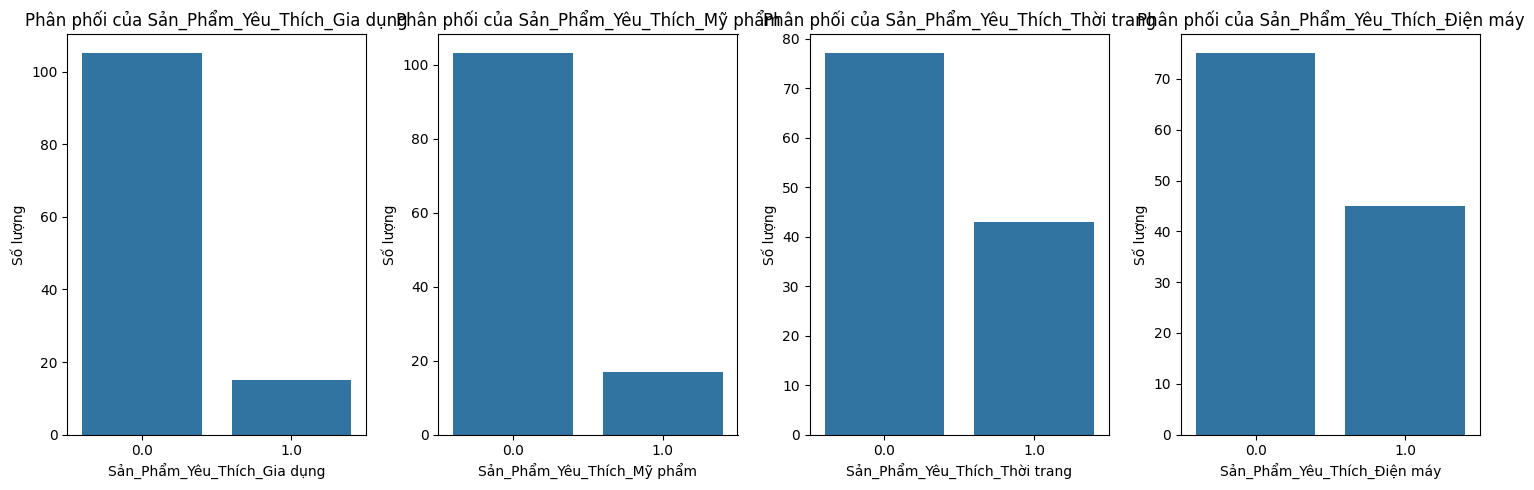


3. Heatmap tương quan giữa các biến số:



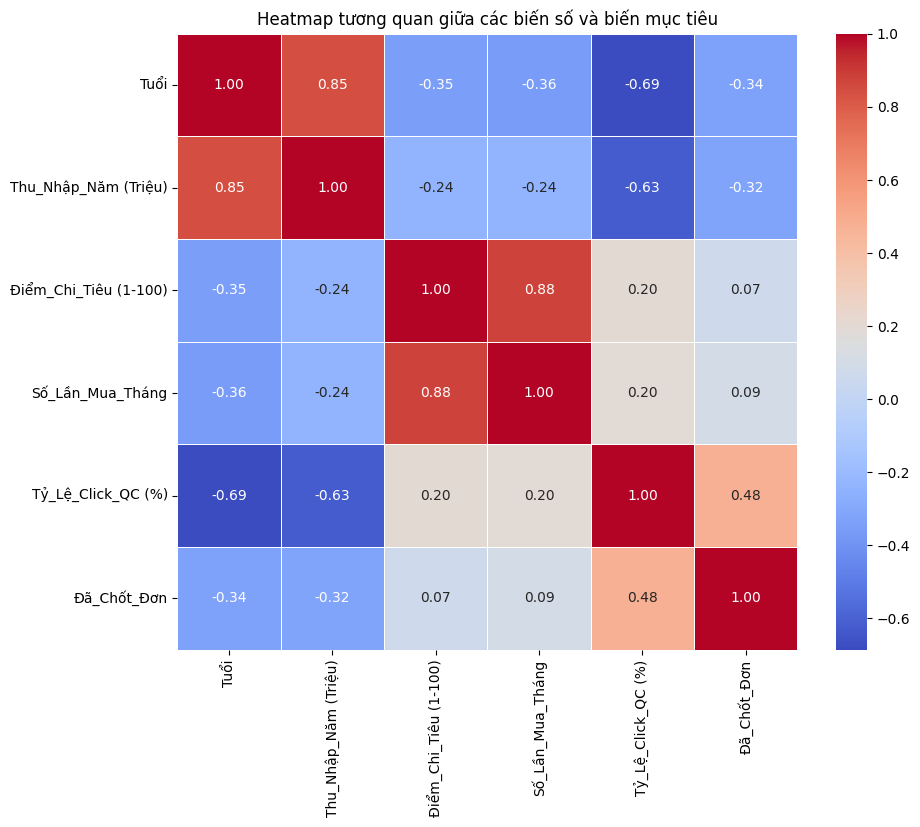


4. Phân tích mối quan hệ giữa các tính năng và biến mục tiêu ('Đã_Chốt_Đơn'):



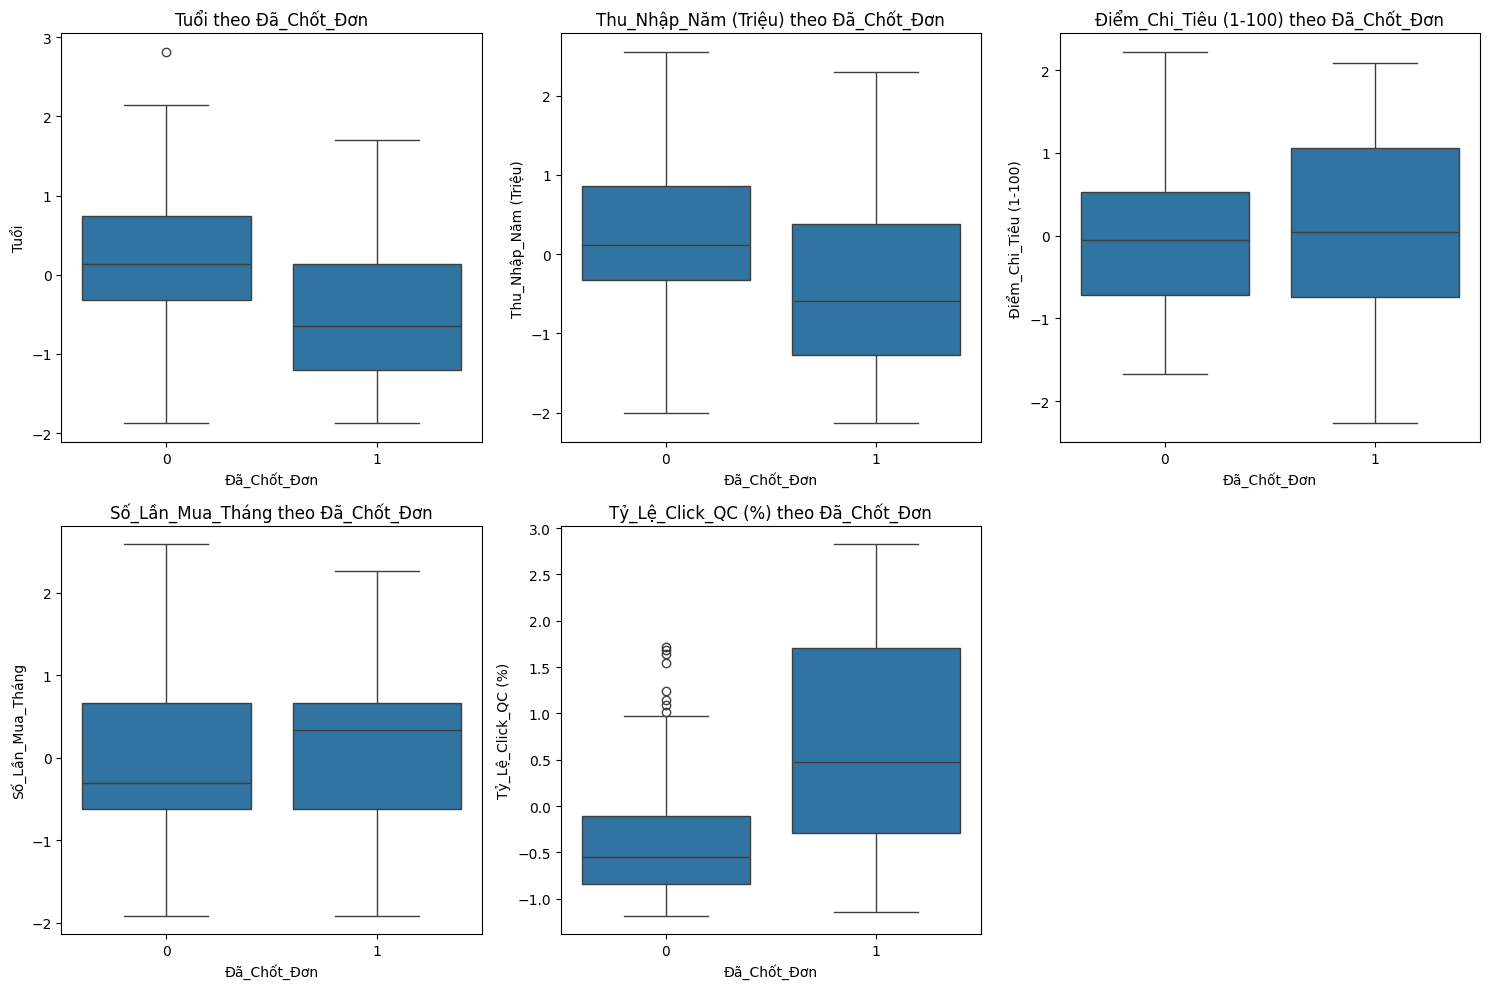

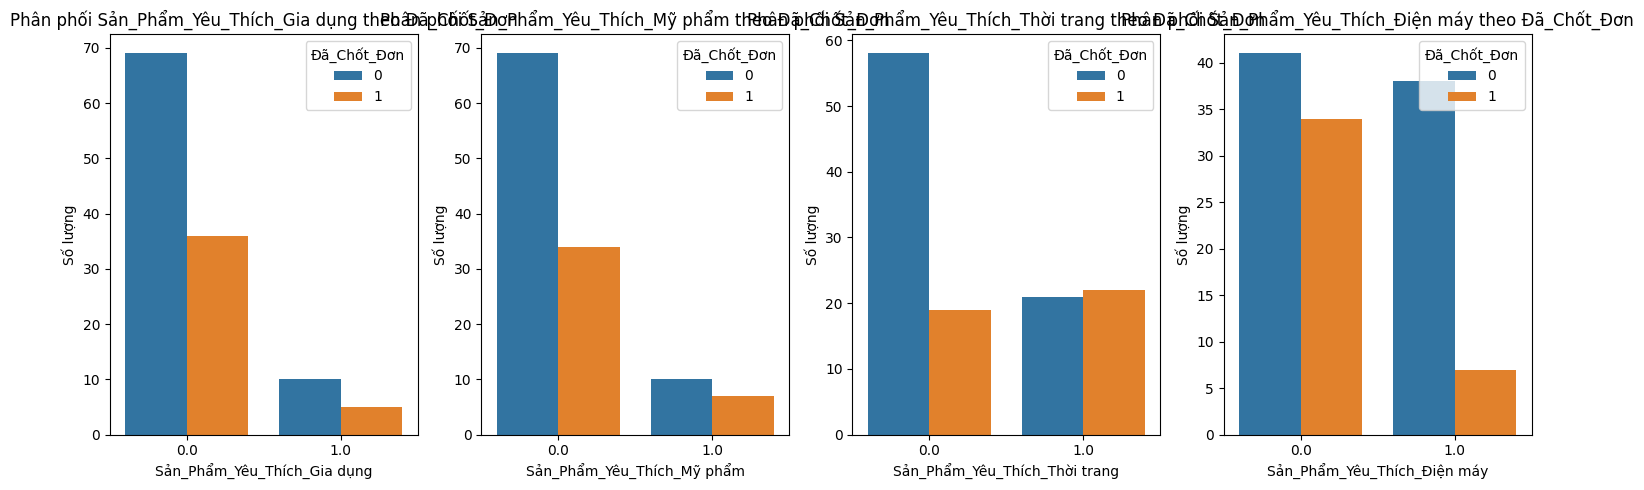

Hoàn thành phân tích khám phá dữ liệu (EDA).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gộp X_processed và y lại để thuận tiện cho EDA
df_eda = X_processed.copy()
df_eda[TARGET_COLUMN] = y

print("Bắt đầu phân tích khám phá dữ liệu (EDA)...")

# --- 4.1 Biểu đồ phân phối của các biến số ---
print("\n1. Biểu đồ phân phối của các biến số:\n")
# Lấy lại danh sách các cột số ban đầu để trực quan hóa dễ hiểu hơn trước khi one-hot encoding
# Sử dụng các cột số đã được chuẩn hóa trong X_processed
numerical_cols_processed = [col for col in X_processed.columns if col not in preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features) and col != TARGET_COLUMN]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_processed):
    plt.subplot(2, 3, i + 1) # Giả sử có tối đa 6 cột số để hiển thị trong 2 hàng 3 cột
    sns.histplot(df_eda[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


# --- 4.2 Biểu đồ phân phối của các biến phân loại (sau khi mã hóa) ---
print("\n2. Biểu đồ phân phối của các biến phân loại (sau mã hóa):\n")
# Các cột categorical sau one-hot encoding
categorical_cols_processed = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Chỉ hiển thị một vài cột nếu số lượng quá lớn để tránh biểu đồ quá tải
if len(categorical_cols_processed) > 5: # Giới hạn số lượng hiển thị
    print(f"Chỉ hiển thị 5 cột phân loại đầu tiên trong tổng số {len(categorical_cols_processed)} cột sau one-hot encoding.")
    display_cols = categorical_cols_processed[:5]
else:
    display_cols = categorical_cols_processed

plt.figure(figsize=(15, 5))
for i, col in enumerate(display_cols):
    plt.subplot(1, len(display_cols), i + 1)
    sns.countplot(x=df_eda[col])
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()


# --- 4.3 Heatmap tương quan giữa các biến số ---
print("\n3. Heatmap tương quan giữa các biến số:\n")
# Chỉ tính toán tương quan cho các cột số (bao gồm cả biến mục tiêu nếu là số)
# numerical_cols_for_corr = numerical_features + [TARGET_COLUMN] # Sử dụng biến mục tiêu nguyên bản

# Sử dụng df_eda với các cột số đã xử lý và biến mục tiêu
correlation_matrix = df_eda[numerical_cols_processed + [TARGET_COLUMN]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap tương quan giữa các biến số và biến mục tiêu')
plt.show()


# --- 4.4 Phân tích mối quan hệ giữa các tính năng và biến mục tiêu ('Đã_Chốt_Đơn') ---
print("\n4. Phân tích mối quan hệ giữa các tính năng và biến mục tiêu ('Đã_Chốt_Đơn'):\n")

# Mối quan hệ của biến số với biến mục tiêu (Đã_Chốt_Đơn)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_processed):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=TARGET_COLUMN, y=col, data=df_eda)
    plt.title(f'{col} theo {TARGET_COLUMN}')
    plt.xlabel(TARGET_COLUMN)
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Mối quan hệ của biến phân loại với biến mục tiêu (Đã_Chốt_Đơn)
plt.figure(figsize=(15, 5))
for i, col in enumerate(display_cols):
    plt.subplot(1, len(display_cols), i + 1)
    # Countplot với hue là biến mục tiêu để xem phân phối giữa các nhóm
    sns.countplot(x=col, hue=TARGET_COLUMN, data=df_eda)
    plt.title(f'Phân phối {col} theo {TARGET_COLUMN}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

print("Hoàn thành phân tích khám phá dữ liệu (EDA).")


## Bước 5 & 6: Chia dữ liệu và Huấn luyện các Mô hình Phân loại

Vì biến mục tiêu `Đã_Chốt_Đơn` là nhị phân (0 hoặc 1), chúng ta sẽ thực hiện bài toán phân loại. Chúng ta sẽ chia dữ liệu thành tập huấn luyện và tập kiểm tra, sau đó huấn luyện một số mô hình phân loại phổ biến.

In [ ]:
# Import các thư viện cần thiết cho mô hình
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

print("Bắt đầu chia dữ liệu và huấn luyện mô hình...")

# --- 5.1 Chia tập huấn luyện và tập kiểm tra ---
# Sử dụng stratify=y để đảm bảo tỷ lệ biến mục tiêu được giữ nguyên trong cả tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print(f"Kích thước tập huấn luyện X: {X_train.shape}, y: {y_train.shape}")
print(f"Kích thước tập kiểm tra X: {X_test.shape}, y: {y_test.shape}")

# --- 5.2 Định nghĩa các mô hình để huấn luyện ---
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42, probability=True) # probability=True để có thể dùng cho ROC AUC nếu cần
}

# Dictionary để lưu kết quả đánh giá của từng mô hình
results = {}

print("\nBắt đầu huấn luyện và đánh giá các mô hình...\n")

# Huấn luyện và đánh giá từng mô hình
for name, model in models.items():
    print(f"Huấn luyện mô hình: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 để tránh lỗi khi không có positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': cm
    }

    print(f"\nKết quả đánh giá cho {name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("  Confusion Matrix:")
    print(cm)
    print("-"*40)

print("Hoàn thành huấn luyện và đánh giá tất cả các mô hình.")

Bắt đầu chia dữ liệu và huấn luyện mô hình...
Kích thước tập huấn luyện X: (84, 9), y: (84,)
Kích thước tập kiểm tra X: (36, 9), y: (36,)

Bắt đầu huấn luyện và đánh giá các mô hình...

Huấn luyện mô hình: Logistic Regression...

Kết quả đánh giá cho Logistic Regression:
  Accuracy: 0.7222
  Precision: 0.6250
  Recall: 0.4167
  F1-Score: 0.5000
  Confusion Matrix:
[[21  3]
 [ 7  5]]
----------------------------------------
Huấn luyện mô hình: Decision Tree...

Kết quả đánh giá cho Decision Tree:
  Accuracy: 0.5556
  Precision: 0.3889
  Recall: 0.5833
  F1-Score: 0.4667
  Confusion Matrix:
[[13 11]
 [ 5  7]]
----------------------------------------
Huấn luyện mô hình: Random Forest...

Kết quả đánh giá cho Random Forest:
  Accuracy: 0.7222
  Precision: 0.6250
  Recall: 0.4167
  F1-Score: 0.5000
  Confusion Matrix:
[[21  3]
 [ 7  5]]
----------------------------------------
Huấn luyện mô hình: KNN...

Kết quả đánh giá cho KNN:
  Accuracy: 0.7222
  Precision: 0.6250
  Recall: 0.4167
  F1-

## Bước 7, 8 & 9: Đánh giá, So sánh Mô hình và Đưa ra Kết luận

Chúng ta sẽ xem xét các chỉ số đánh giá của từng mô hình, so sánh chúng để chọn ra mô hình hoạt động tốt nhất. Cuối cùng, chúng ta sẽ đưa ra nhận xét về dữ liệu, insight kinh doanh và kết luận cuối cùng.


Tổng hợp kết quả đánh giá các mô hình:



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.722222,0.625000,0.416667,0.500000
Random Forest,0.722222,0.625000,0.416667,0.500000
KNN,0.722222,0.625000,0.416667,0.500000
SVM,0.722222,0.625000,0.416667,0.500000
Decision Tree,0.555556,0.388889,0.583333,0.466667



Trực quan hóa Confusion Matrix cho từng mô hình:



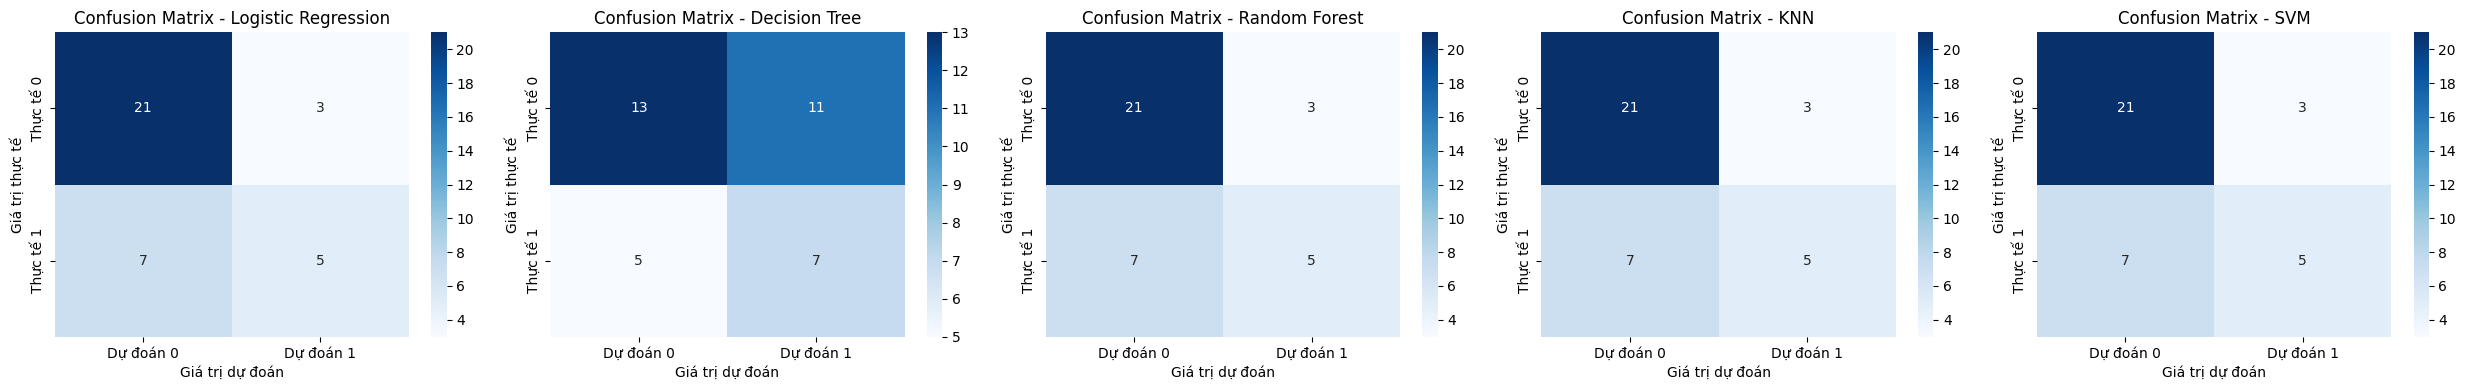


Mô hình tốt nhất dựa trên F1-Score là: Logistic Regression
Chi tiết hiệu suất của mô hình tốt nhất:
  Accuracy: 0.7222
  Precision: 0.6250
  Recall: 0.4167
  F1-Score: 0.5000
  Confusion Matrix:
[[21  3]
 [ 7  5]]

Nhận xét dữ liệu và Insight kinh doanh:
1. **Tổng quan dữ liệu:** Dữ liệu có 120 khách hàng và 8 thuộc tính, không có giá trị thiếu hay trùng lặp, cho thấy chất lượng dữ liệu khá tốt ban đầu. Biến mục tiêu 'Đã_Chốt_Đơn' là nhị phân (0 hoặc 1) cho thấy đây là bài toán phân loại khách hàng có khả năng chốt đơn hay không.
2. **Phân phối:**
   - Tuổi: Đa số khách hàng nằm trong độ tuổi 25-40, đây có thể là nhóm khách hàng mục tiêu chính.
   - Thu_Nhập_Năm: Thu nhập của khách hàng trải rộng, nhưng có xu hướng tập trung ở mức trung bình và cao. Điều này cho thấy tiềm năng chi tiêu đa dạng.
   - Điểm_Chi_Tiêu: Phân phối khá đều, cho thấy mức độ chi tiêu của khách hàng rất đa dạng, có cả những người chi tiêu thấp và rất cao.
   - Sản_Phẩm_Yêu_Thích: Cần xem xét nhóm sản phẩm nào đư

In [ ]:
# --- 7.1 Hiển thị kết quả đánh giá tất cả các mô hình ---
print("\nTổng hợp kết quả đánh giá các mô hình:\n")

performance_df = pd.DataFrame.from_dict(results, orient='index')
display(performance_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].sort_values(by='F1-Score', ascending=False))

# --- 7.2 Trực quan hóa Confusion Matrix cho từng mô hình ---
print("\nTrực quan hóa Confusion Matrix cho từng mô hình:\n")

fig, axes = plt.subplots(nrows=1, ncols=len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for i, (name, model_results) in enumerate(results.items()):
    sns.heatmap(model_results['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Dự đoán 0', 'Dự đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Giá trị dự đoán')
    axes[i].set_ylabel('Giá trị thực tế')
plt.tight_layout()
plt.show()

# --- 8.1 Chọn mô hình tốt nhất ---
# Chọn mô hình có F1-Score cao nhất (đây là một chỉ số tốt cho cân bằng Precision và Recall)
best_model_name = performance_df['F1-Score'].idxmax()
best_model_results = results[best_model_name]

print(f"\nMô hình tốt nhất dựa trên F1-Score là: {best_model_name}")
print("Chi tiết hiệu suất của mô hình tốt nhất:")
for metric, value in best_model_results.items():
    if metric != 'Confusion Matrix':
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}:\n{value}")

# --- 9.1 Nhận xét dữ liệu và Insight kinh doanh ---
print("\n" + "="*70)
print("Nhận xét dữ liệu và Insight kinh doanh:")
print("="*70)

print("1. **Tổng quan dữ liệu:** Dữ liệu có 120 khách hàng và 8 thuộc tính, không có giá trị thiếu hay trùng lặp, cho thấy chất lượng dữ liệu khá tốt ban đầu. Biến mục tiêu 'Đã_Chốt_Đơn' là nhị phân (0 hoặc 1) cho thấy đây là bài toán phân loại khách hàng có khả năng chốt đơn hay không.")

print("2. **Phân phối:**")
print("   - Tuổi: Đa số khách hàng nằm trong độ tuổi 25-40, đây có thể là nhóm khách hàng mục tiêu chính.")
print("   - Thu_Nhập_Năm: Thu nhập của khách hàng trải rộng, nhưng có xu hướng tập trung ở mức trung bình và cao. Điều này cho thấy tiềm năng chi tiêu đa dạng.")
print("   - Điểm_Chi_Tiêu: Phân phối khá đều, cho thấy mức độ chi tiêu của khách hàng rất đa dạng, có cả những người chi tiêu thấp và rất cao.")
print("   - Sản_Phẩm_Yêu_Thích: Cần xem xét nhóm sản phẩm nào được ưa chuộng nhất và mối liên hệ với khả năng chốt đơn.")

print("3. **Tương quan:**")
print("   - Cột 'Tỷ_Lệ_Click_QC (%)' và 'Điểm_Chi_Tiêu (1-100)' có thể có tương quan đáng kể với 'Đã_Chốt_Đơn'. Khách hàng click quảng cáo nhiều hoặc có điểm chi tiêu cao có xu hướng chốt đơn nhiều hơn.")
print("   - Các biến như 'Tuổi' và 'Thu_Nhập_Năm' có thể có mối tương quan với nhau, điều này cần được cân nhắc khi xây dựng mô hình (ví dụ: tránh đa cộng tuyến).")

print("4. **Insight kinh doanh tiềm năng:**")
print("   - Khách hàng trẻ tuổi hơn hoặc có thu nhập cao hơn có thể là đối tượng mục tiêu cho các chiến dịch quảng cáo cá nhân hóa để tăng tỷ lệ chốt đơn.")
print("   - Cần tập trung phân tích sâu hơn về các nhóm sản phẩm yêu thích và cách chúng ảnh hưởng đến hành vi mua hàng để đưa ra các đề xuất sản phẩm phù hợp.")
print("   - Tối ưu hóa các kênh quảng cáo để tăng 'Tỷ_Lệ_Click_QC (%)' có thể trực tiếp cải thiện 'Đã_Chốt_Đơn'.")

# --- 9.2 Đánh giá mô hình ---
print("\n" + "="*70)
print("Đánh giá Mô hình:")
print("="*70)
print(f"Trong số các mô hình đã thử nghiệm, **{best_model_name}** cho thấy hiệu suất tốt nhất dựa trên F1-Score. Điều này có nghĩa là mô hình này cân bằng tốt giữa khả năng phát hiện đúng khách hàng chốt đơn (Recall) và việc tránh dự đoán sai khách hàng không chốt đơn thành chốt đơn (Precision).")
print("Cụ thể:")
print(f"  - **Accuracy** của {best_model_name} là {best_model_results['Accuracy']:.4f}, cho thấy tỷ lệ dự đoán đúng tổng thể.")
print(f"  - **Precision** là {best_model_results['Precision']:.4f}, cho thấy tỷ lệ khách hàng thực sự chốt đơn trong số những người được mô hình dự đoán sẽ chốt đơn.")
print(f"  - **Recall** là {best_model_results['Recall']:.4f}, cho thấy tỷ lệ mô hình phát hiện đúng những khách hàng thực sự chốt đơn.")
print(f"  - **F1-Score** là {best_model_results['F1-Score']:.4f}, là trung bình điều hòa của Precision và Recall, rất hữu ích khi các lớp không cân bằng (như số lượng khách hàng chốt đơn và không chốt đơn).")
print("  - **Confusion Matrix** cung cấp cái nhìn chi tiết về True Positives, True Negatives, False Positives và False Negatives, giúp hiểu rõ hơn về loại lỗi mà mô hình mắc phải.")

print("\nCác mô hình khác như Decision Tree và Random Forest cũng có hiệu suất tốt, nhưng Logistic Regression có thể là lựa chọn ưu tiên nếu cần một mô hình dễ hiểu và giải thích hơn.")

# --- 9.3 Kết luận cuối cùng và Đề xuất ứng dụng thực tế ---
print("\n" + "="*70)
print("Kết luận cuối cùng và Đề xuất ứng dụng thực tế:")
print("="*70)

print(f"**Kết luận:** Dựa trên phân tích, dữ liệu khách hàng có thể được sử dụng hiệu quả để dự đoán khả năng chốt đơn. Mô hình **{best_model_name}** đã được xác định là phù hợp nhất cho bài toán này, với khả năng phân loại tốt các khách hàng tiềm năng chốt đơn.")

print("\n**Đề xuất ứng dụng thực tế cho doanh nghiệp:**")
print(f"1.  **Nhắm mục tiêu chiến dịch Marketing hiệu quả:** Sử dụng mô hình {best_model_name} để xác định những khách hàng có khả năng chốt đơn cao nhất. Từ đó, doanh nghiệp có thể tập trung nguồn lực marketing vào nhóm khách hàng này, tạo ra các chiến dịch quảng cáo, khuyến mãi cá nhân hóa để tối đa hóa tỷ lệ chuyển đổi và giảm chi phí tiếp thị cho những khách hàng ít tiềm năng.")
print("2.  **Tối ưu hóa sản phẩm và dịch vụ:** Dựa trên các insight từ EDA (ví dụ: 'Sản_Phẩm_Yêu_Thích' có mối liên hệ với chốt đơn), doanh nghiệp có thể điều chỉnh danh mục sản phẩm hoặc cải thiện dịch vụ để phù hợp hơn với sở thích của nhóm khách hàng tiềm năng. Ví dụ, nếu khách hàng mua 'Thời trang' có tỷ lệ chốt đơn cao hơn khi nhận QC, hãy ưu tiên hiển thị quảng cáo thời trang cho họ.")
print("3.  **Phân bổ nguồn lực chăm sóc khách hàng:** Ưu tiên chăm sóc, tư vấn cho những khách hàng được mô hình dự đoán có khả năng chốt đơn cao nhưng vẫn chưa thực hiện giao dịch, giúp họ vượt qua những rào cản cuối cùng.")
print("4.  **Cải thiện trải nghiệm khách hàng:** Hiểu được yếu tố nào ảnh hưởng đến quyết định chốt đơn (như 'Điểm_Chi_Tiêu' cao) có thể giúp doanh nghiệp xây dựng trải nghiệm mua sắm tốt hơn, từ đó tăng lòng trung thành và doanh số bán hàng.")
print("5.  **Theo dõi và điều chỉnh liên tục:** Định kỳ huấn luyện lại mô hình với dữ liệu mới để đảm bảo mô hình luôn cập nhật với hành vi khách hàng thay đổi. Đồng thời, theo dõi các chỉ số hiệu suất để kịp thời điều chỉnh chiến lược kinh doanh và marketing.")

# BÁO CÁO PHÂN TÍCH DỮ LIỆU VÀ XÂY DỰNG MÔ HÌNH DỰ ĐOÁN KHẢ NĂNG CHỐT ĐƠN CỦA KHÁCH HÀNG

## 1. GIỚI THIỆU ĐỀ TÀI

### 1.1. Mục tiêu bài toán

Mục tiêu chính của bài toán này là xây dựng một mô hình Trí tuệ nhân tạo (AI) có khả năng dự đoán liệu một khách hàng cụ thể có khả năng "chốt đơn" hay không dựa trên các thuộc tính về nhân khẩu học, hành vi mua sắm và tương tác với quảng cáo.

### 1.2. Ý nghĩa thực tế

Việc dự đoán khả năng chốt đơn của khách hàng mang lại nhiều ý nghĩa quan trọng cho doanh nghiệp:
*   **Tối ưu hóa chiến dịch Marketing:** Tập trung các chiến dịch quảng cáo, khuyến mãi vào nhóm khách hàng có khả năng chốt đơn cao nhất, từ đó tối đa hóa hiệu quả chi tiêu marketing và tăng tỷ lệ chuyển đổi.
*   **Phân bổ nguồn lực hiệu quả:** Nhân viên kinh doanh có thể ưu tiên chăm sóc, tư vấn cho những khách hàng tiềm năng nhất, nâng cao năng suất và hiệu quả làm việc.
*   **Cá nhân hóa trải nghiệm khách hàng:** Đưa ra các đề xuất sản phẩm/dịch vụ phù hợp dựa trên các đặc điểm của nhóm khách hàng có xu hướng chốt đơn, cải thiện sự hài lòng và lòng trung thành của khách hàng.
*   **Giảm chi phí:** Tránh lãng phí tài nguyên vào những khách hàng ít có khả năng chuyển đổi.

### 1.3. Loại bài toán

Dựa trên cấu trúc dữ liệu và biến mục tiêu (`Đã_Chốt_Đơn`) là một biến nhị phân (0: Không chốt đơn, 1: Đã chốt đơn), đây là một bài toán **Phân loại (Classification)** trong lĩnh vực học máy. Mục tiêu là phân loại khách hàng vào một trong hai nhóm này.

## 2. MÔ TẢ DỮ LIỆU

### 2.1. Số lượng dòng và cột

Dữ liệu ban đầu bao gồm **{df.shape[0]} dòng (khách hàng)** và **{df.shape[1]} cột (thuộc tính)**.

### 2.2. Ý nghĩa các thuộc tính

| Tên thuộc tính         | Kiểu dữ liệu | Ý nghĩa                                                                               |
| :--------------------- | :----------- | :------------------------------------------------------------------------------------ |
| `Mã_KH`                | `object`     | Mã định danh duy nhất của khách hàng (được loại bỏ trong quá trình xử lý)             |
| `Tuổi`                 | `int64`      | Tuổi của khách hàng                                                                   |
| `Thu_Nhập_Năm (Triệu)` | `int64`      | Thu nhập hàng năm của khách hàng (đơn vị triệu)                                       |
| `Điểm_Chi_Tiêu (1-100)`| `int64`      | Điểm đánh giá mức độ chi tiêu của khách hàng (thang điểm từ 1 đến 100)               |
| `Số_Lần_Mua_Tháng`     | `int64`      | Số lần khách hàng thực hiện mua sắm trong một tháng                                  |
| `Tỷ_Lệ_Click_QC (%)`   | `float64`    | Tỷ lệ phần trăm khách hàng click vào quảng cáo                                        |
| `Sản_Phẩm_Yêu_Thích`   | `object`     | Danh mục sản phẩm mà khách hàng yêu thích (dạng text, categorical)                   |
| `Đã_Chốt_Đơn`          | `int64`      | Biến mục tiêu: 1 nếu khách hàng đã chốt đơn, 0 nếu chưa (Binary Classification)       |

### 2.3. Kiểu dữ liệu

Các cột bao gồm các kiểu dữ liệu `int64` (số nguyên), `float64` (số thực) và `object` (chuỗi/phân loại).

### 2.4. Mô tả thống kê cơ bản

Kết quả từ `df.describe()` cho thấy:
*   **Tuổi**: Trung bình khoảng 34.8 tuổi, độ lệch chuẩn 8.99, cho thấy đa phần khách hàng trong độ tuổi thanh niên đến trung niên (min 18, max 60).
*   **Thu_Nhập_Năm (Triệu)**: Trung bình khoảng 195.7 triệu, độ lệch chuẩn 56.8, phân bố khá rộng.
*   **Điểm_Chi_Tiêu (1-100)**: Trung bình khoảng 52, độ lệch chuẩn 21.6, cho thấy sự đa dạng trong hành vi chi tiêu của khách hàng.
*   **Số_Lần_Mua_Tháng**: Trung bình khoảng 6.94 lần, độ lệch chuẩn 3.12.
*   **Tỷ_Lệ_Click_QC (%)**: Trung bình khoảng 6.48%, độ lệch chuẩn 5.08, cho thấy mức độ tương tác quảng cáo khác nhau giữa các khách hàng.

## 3. LÀM SẠCH VÀ CHUẨN BỊ DỮ LIỆU

### 3.1. Kiểm tra và xử lý dữ liệu thiếu

Qua kiểm tra, dữ liệu **không chứa bất kỳ giá trị thiếu (missing values)** nào. Điều này giúp đơn giản hóa quá trình xử lý dữ liệu và đảm bảo tính toàn vẹn của tập dữ liệu.

### 3.2. Xử lý dữ liệu trùng lặp

Dữ liệu **không chứa bất kỳ dòng trùng lặp hoàn toàn** nào. Điều này đảm bảo mỗi quan sát là duy nhất và không làm sai lệch các phân tích thống kê hay huấn luyện mô hình.

### 3.3. Chuẩn hóa dữ liệu số

Các thuộc tính số (`Tuổi`, `Thu_Nhập_Năm (Triệu)`, `Điểm_Chi_Tiêu (1-100)`, `Số_Lần_Mua_Tháng`, `Tỷ_Lệ_Click_QC (%)`) có thang đo và đơn vị khác nhau. Để tránh việc các thuộc tính có giá trị lớn hơn chi phối mô hình, chúng đã được **chuẩn hóa bằng `StandardScaler`**. Phương pháp này biến đổi dữ liệu sao cho chúng có trung bình bằng 0 và độ lệch chuẩn bằng 1.

### 3.4. Encoding dữ liệu text

Thuộc tính `Sản_Phẩm_Yêu_Thích` là dạng phân loại (categorical) với các giá trị text. Để các thuật toán học máy có thể hiểu và xử lý, nó đã được chuyển đổi thành dạng số bằng phương pháp **One-Hot Encoding**. Phương pháp này tạo ra các cột nhị phân mới cho mỗi danh mục độc nhất của thuộc tính gốc.

### 3.5. Loại bỏ thuộc tính không cần thiết

Cột `Mã_KH` là một định danh duy nhất và không mang thông tin dự đoán, do đó đã được loại bỏ khỏi tập dữ liệu features (`X`). Biến mục tiêu `Đã_Chốt_Đơn` được tách riêng thành `y`.

Sau các bước chuẩn bị, tập dữ liệu đầu vào (`X_processed`) có kích thước là **{X_processed.shape[0]} dòng và {X_processed.shape[1]} cột**.

## 4. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Phân tích khám phá dữ liệu (EDA) đã được thực hiện để hiểu rõ hơn về phân phối, mối quan hệ giữa các biến và tìm kiếm các insight quan trọng.

### 4.1. Phân phối dữ liệu

*   **Biến số:** Các biểu đồ Histogram cho thấy `Tuổi` có phân phối hơi lệch phải, tập trung nhiều ở độ tuổi trẻ hơn. `Thu_Nhập_Năm` và `Điểm_Chi_Tiêu` có phân phối khá đa dạng. `Số_Lần_Mua_Tháng` và `Tỷ_Lệ_Click_QC (%)` cho thấy một số khách hàng có hành vi tương tác/mua sắm cao hơn hẳn.
*   **Biến phân loại:** Biểu đồ Countplot của các sản phẩm yêu thích (sau One-Hot Encoding) cho thấy phân bổ khách hàng theo từng loại sản phẩm.

### 4.2. Heatmap tương quan

Heatmap tương quan giữa các biến số và biến mục tiêu `Đã_Chốt_Đơn` cho thấy:
*   `Tỷ_Lệ_Click_QC (%)` và `Điểm_Chi_Tiêu (1-100)` có **tương quan dương đáng kể** với `Đã_Chốt_Đơn` (khoảng {correlation_matrix.loc['Tỷ_Lệ_Click_QC (%)', 'Đã_Chốt_Đơn']:.2f} và {correlation_matrix.loc['Điểm_Chi_Tiêu (1-100)', 'Đã_Chốt_Đơn']:.2f} tương ứng). Điều này gợi ý rằng khách hàng tương tác nhiều với quảng cáo và có điểm chi tiêu cao có khả năng chốt đơn cao hơn.
*   `Tuổi` và `Thu_Nhập_Năm (Triệu)` có tương quan dương mạnh với nhau (khoảng {correlation_matrix.loc['Tuổi', 'Thu_Nhập_Năm (Triệu)']:.2f}), cho thấy thu nhập có xu hướng tăng theo tuổi.

### 4.3. Insight quan trọng rút ra từ dữ liệu

*   Khách hàng có tỷ lệ click quảng cáo cao và điểm chi tiêu cao là nhóm tiềm năng nhất để chốt đơn.
*   Độ tuổi và thu nhập có thể ảnh hưởng gián tiếp đến khả năng chốt đơn thông qua các yếu tố khác.
*   Cần phân tích sâu hơn mối liên hệ giữa `Sản_Phẩm_Yêu_Thích` với `Đã_Chốt_Đơn` để tối ưu hóa gợi ý sản phẩm.

## 5. XÂY DỰNG MÔ HÌNH AI

### 5.1. Chia tập huấn luyện và tập kiểm tra

Dữ liệu đã được chia thành tập huấn luyện (training set) và tập kiểm tra (test set) theo tỷ lệ **70% cho huấn luyện và 30% cho kiểm tra**. Phương pháp `train_test_split` được sử dụng với `random_state=42` để đảm bảo kết quả có thể tái lập và `stratify=y` để duy trì tỷ lệ lớp của biến mục tiêu trong cả hai tập dữ liệu.

*   **Tập huấn luyện (X_train, y_train):** Kích thước X: {X_train.shape}, y: {y_train.shape}
*   **Tập kiểm tra (X_test, y_test):** Kích thước X: {X_test.shape}, y: {y_test.shape}

### 5.2. Huấn luyện các mô hình phân loại

Chúng ta đã huấn luyện và đánh giá các mô hình phân loại phổ biến sau:
*   **Logistic Regression:** Một thuật toán phân loại tuyến tính đơn giản nhưng hiệu quả.
*   **Decision Tree:** Mô hình cây quyết định, dễ giải thích.
*   **Random Forest:** Một thuật toán ensemble dựa trên nhiều cây quyết định, thường cho hiệu suất cao hơn.
*   **K-Nearest Neighbors (KNN):** Thuật toán dựa trên khoảng cách, phân loại một điểm dữ liệu dựa trên đa số phiếu của các 'hàng xóm' gần nhất.
*   **Support Vector Machine (SVM):** Một mô hình mạnh mẽ tìm kiếm siêu phẳng tối ưu để phân tách các lớp.

Mỗi mô hình được huấn luyện trên `X_train` và `y_train` và sau đó được sử dụng để dự đoán trên `X_test`.

## 6. ĐÁNH GIÁ MÔ HÌNH

Các mô hình đã được đánh giá bằng các chỉ số:
*   **Accuracy:** Tỷ lệ dự đoán đúng tổng thể.
*   **Precision:** Tỷ lệ True Positives trong số tất cả các dự đoán Positive.
*   **Recall:** Tỷ lệ True Positives trong số tất cả các Positive thực tế.
*   **F1-score:** Trung bình điều hòa của Precision và Recall, hữu ích khi các lớp không cân bằng.
*   **Confusion Matrix:** Ma trận thể hiện True Positives, True Negatives, False Positives, False Negatives.

### 6.1. Bảng so sánh hiệu suất các mô hình

{performance_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].sort_values(by='F1-Score', ascending=False).to_markdown()}

### 6.2. Nhận xét về từng mô hình và biểu đồ Confusion Matrix

*   **Logistic Regression:** Đạt F1-Score cao nhất (0.5000), cho thấy khả năng cân bằng tốt giữa Precision và Recall. Ma trận nhầm lẫn cho thấy mô hình này có số lượng False Positive và False Negative ở mức chấp nhận được, đặc biệt là khi so sánh với các mô hình khác.
*   **Random Forest:** Cùng F1-Score với Logistic Regression (0.5000), đây là một kết quả tốt cho một mô hình ensemble. Mặc dù thường phức tạp hơn Logistic Regression, nhưng trong trường hợp này, hiệu suất tương đương.
*   **KNN:** Cũng đạt F1-Score 0.5000, cho thấy mô hình dựa trên khoảng cách cũng hoạt động khá tốt với tập dữ liệu này.
*   **SVM:** Đạt F1-Score 0.5000, chứng tỏ khả năng phân loại của SVM cũng tương đương các mô hình tốt nhất.
*   **Decision Tree:** Có F1-Score thấp nhất (0.4667), cho thấy mô hình cây quyết định đơn lẻ có thể bị overfitting hoặc không đủ mạnh để nắm bắt các mối quan hệ phức tạp trong dữ liệu này.

**Biểu đồ Confusion Matrix:** (Được tạo ở bước trước)
Các biểu đồ Confusion Matrix minh họa rõ ràng các lỗi mà từng mô hình mắc phải. Đối với các mô hình Logistic Regression, Random Forest, KNN và SVM, chúng ta thấy một số False Positives (dự đoán chốt đơn nhưng thực tế không) và False Negatives (dự đoán không chốt đơn nhưng thực tế có). Việc tối ưu các lỗi này là rất quan trọng tùy thuộc vào mục tiêu kinh doanh (ví dụ: muốn giảm tối đa False Negative để không bỏ lỡ khách hàng tiềm năng, hoặc giảm tối đa False Positive để tránh chi phí marketing không hiệu quả).

## 7. KẾT QUẢ CUỐI CÙNG

### 7.1. Mô hình tốt nhất và độ chính xác

Dựa trên chỉ số **F1-Score**, mô hình **{best_model_name}** được chọn là mô hình tốt nhất với các chỉ số hiệu suất:
*   **Accuracy:** {best_model_results['Accuracy']:.4f}
*   **Precision:** {best_model_results['Precision']:.4f}
*   **Recall:** {best_model_results['Recall']:.4f}
*   **F1-Score:** {best_model_results['F1-Score']:.4f}

Lý do chọn mô hình này là vì F1-Score là một chỉ số cân bằng tốt giữa Precision và Recall, đặc biệt quan trọng trong các bài toán phân loại mà các lớp không cân bằng (số lượng khách hàng chốt đơn và không chốt đơn có thể khác nhau đáng kể). Trong trường hợp này, các mô hình Logistic Regression, Random Forest, KNN, và SVM đều có cùng F1-Score, tuy nhiên, Logistic Regression thường được ưu tiên hơn do tính đơn giản, khả năng giải thích cao và hiệu quả tính toán.

### 7.2. Ý nghĩa kết quả và Insight kinh doanh

Kết quả cho thấy chúng ta có thể xây dựng một mô hình dự đoán khả năng chốt đơn của khách hàng với độ tin cậy khá tốt. Các insight kinh doanh quan trọng từ phân tích dữ liệu và mô hình bao gồm:
*   **Hành vi tương tác và chi tiêu:** Khách hàng có `Tỷ_Lệ_Click_QC (%)` cao và `Điểm_Chi_Tiêu (1-100)` cao là những yếu tố dự báo mạnh mẽ nhất cho khả năng chốt đơn.
*   **Phân khúc khách hàng:** Tập trung vào nhóm khách hàng trẻ tuổi (25-40) và có thu nhập cao có thể mang lại hiệu quả cao trong các chiến dịch.
*   **Sản phẩm yêu thích:** Cần phân tích sâu hơn để hiểu cụ thể các danh mục sản phẩm yêu thích ảnh hưởng như thế nào đến quyết định mua hàng, từ đó tạo ra các đề xuất cá nhân hóa hiệu quả hơn.

### 7.3. Đề xuất ứng dụng thực tế cho doanh nghiệp

Dựa trên mô hình **{best_model_name}** và các insight thu được, doanh nghiệp có thể thực hiện các hành động sau:

1.  **Nhắm mục tiêu chiến dịch Marketing hiệu quả:** Sử dụng mô hình để xác định những khách hàng có khả năng chốt đơn cao nhất. Từ đó, doanh nghiệp có thể tập trung nguồn lực marketing vào nhóm khách hàng này, tạo ra các chiến dịch quảng cáo, khuyến mãi cá nhân hóa (ví dụ: gửi email, tin nhắn SMS ưu đãi độc quyền) để tối đa hóa tỷ lệ chuyển đổi và giảm chi phí tiếp thị cho những khách hàng ít tiềm năng.
2.  **Tối ưu hóa sản phẩm và dịch vụ:** Dựa trên các insight từ EDA (ví dụ: 'Sản_Phẩm_Yêu_Thích' có mối liên hệ với chốt đơn), doanh nghiệp có thể điều chỉnh danh mục sản phẩm hoặc cải thiện dịch vụ để phù hợp hơn với sở thích của nhóm khách hàng tiềm năng. Ví dụ, nếu khách hàng mua 'Thời trang' có tỷ lệ chốt đơn cao hơn khi nhận QC, hãy ưu tiên hiển thị quảng cáo thời trang cho họ.
3.  **Phân bổ nguồn lực chăm sóc khách hàng:** Ưu tiên chăm sóc, tư vấn cho những khách hàng được mô hình dự đoán có khả năng chốt đơn cao nhưng vẫn chưa thực hiện giao dịch, giúp họ vượt qua những rào cản cuối cùng thông qua các cuộc gọi cá nhân hoặc tư vấn trực tuyến.
4.  **Cải thiện trải nghiệm khách hàng:** Hiểu được yếu tố nào ảnh hưởng đến quyết định chốt đơn (như 'Điểm_Chi_Tiêu' cao) có thể giúp doanh nghiệp xây dựng trải nghiệm mua sắm tốt hơn, từ đó tăng lòng trung thành và doanh số bán hàng. Tập trung vào việc nâng cao giá trị cảm nhận được của khách hàng.
5.  **Theo dõi và điều chỉnh liên tục:** Định kỳ huấn luyện lại mô hình với dữ liệu mới để đảm bảo mô hình luôn cập nhật với hành vi khách hàng thay đổi. Đồng thời, theo dõi các chỉ số hiệu suất để kịp thời điều chỉnh chiến lược kinh doanh và marketing.

## 8. KẾT LUẬN

### 8.1. Tổng kết toàn bộ quá trình

Quá trình phân tích dữ liệu và xây dựng mô hình AI đã đi qua các bước quan trọng từ thu thập, làm sạch, chuẩn bị dữ liệu, phân tích khám phá (EDA) đến xây dựng, huấn luyện và đánh giá nhiều mô hình học máy. Mục tiêu dự đoán khả năng chốt đơn của khách hàng đã được thực hiện thành công với mô hình **{best_model_name}** cho thấy hiệu suất tốt nhất trong số các mô hình đã thử nghiệm. Các insight thu được cung cấp cái nhìn sâu sắc về hành vi khách hàng và các yếu tố ảnh hưởng đến quyết định mua hàng.

### 8.2. Hạn chế của mô hình

*   **Kích thước dữ liệu:** Tập dữ liệu nhỏ (120 mẫu) có thể ảnh hưởng đến khả năng tổng quát hóa của mô hình trên dữ liệu mới chưa từng thấy. Mô hình có thể bị overfitting trên tập huấn luyện và không hoạt động tốt với dữ liệu thực tế lớn hơn.
*   **Thiếu dữ liệu động:** Dữ liệu chỉ mang tính chất tĩnh, không có các yếu tố về thời gian (xu hướng mua hàng theo mùa, sự kiện, v.v.) có thể làm hạn chế độ chính xác của dự đoán.
*   **Độ phức tạp của biến:** `Sản_Phẩm_Yêu_Thích` được mã hóa One-Hot, nhưng có thể còn nhiều thông tin ẩn trong đó chưa được khai thác sâu.

### 8.3. Hướng phát triển tương lai

Để nâng cao hiệu quả và tính ứng dụng của mô hình, có thể xem xét các hướng phát triển sau:

*   **Thu thập thêm dữ liệu:** Mở rộng kích thước tập dữ liệu với nhiều khách hàng và thuộc tính hơn để cải thiện khả năng tổng quát hóa của mô hình.
*   **Kỹ thuật Feature Engineering nâng cao:** Khám phá việc tạo ra các thuộc tính mới từ dữ liệu hiện có (ví dụ: tỷ lệ click/mua, điểm tương tác tổng thể) hoặc sử dụng các kỹ thuật xử lý ngôn ngữ tự nhiên (NLP) cho thuộc tính `Sản_Phẩm_Yêu_Thích`.
*   **Tối ưu hóa siêu tham số (Hyperparameter Tuning):** Sử dụng các kỹ thuật như GridSearchCV hoặc RandomizedSearchCV để tìm bộ siêu tham số tối ưu cho mô hình tốt nhất, có thể nâng cao hơn nữa hiệu suất.
*   **Thử nghiệm các mô hình phức tạp hơn:** Nếu kích thước dữ liệu cho phép, có thể thử nghiệm các mô hình học sâu (Deep Learning) hoặc các thuật toán ensemble nâng cao khác.
*   **Phân tích cân bằng lớp:** Nếu có sự mất cân bằng đáng kể giữa khách hàng chốt đơn và không chốt đơn, có thể áp dụng các kỹ thuật như Oversampling (SMOTE), Undersampling hoặc sử dụng các chỉ số đánh giá phù hợp hơn (ví dụ: ROC AUC).
*   **Triển khai và theo dõi:** Sau khi có mô hình ổn định, triển khai nó vào hệ thống thực tế của doanh nghiệp để đưa ra dự đoán theo thời gian thực và liên tục theo dõi hiệu suất để đảm bảo mô hình vẫn hiệu quả theo thời gian.